<a href="https://colab.research.google.com/github/mysteryea7107/Predicting-Grade-12-STEM-Enrollment-Across-Philippine-Schools-Using-Machine-Learning/blob/main/Notebooks/Predicting_Grade_12_STEM_Enrollment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#A. DATASET EXPLORATION

In [7]:
data <- read_csv("/enrollment_2025-26.csv")

Rows: 60204 Columns: 83
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): school_name, region, division, province, school_district, legislat...
dbl (67): school_id, kinder_male, kinder_female, g1_male, g1_female, g2_male...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
dim(data)

[1] 60204    83

In [10]:
# PREDICTION PROBLEM DEFINITION:
# Can we predict the number of Grade 12 STEM male students in Senior High School–offering schools using school location, characteristics, and other relevant school-level variables?
# Target Variable: g12_stem_male (Continuous count of Grade 12 male STEM students)
# Task Type: Regression (because the target is a continuous numeric count)

In [11]:
#B. DATASET EXPLORATION

In [17]:
summary(data$g12_stem_male)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 

In [ ]:
# (a) Number of Observations and Variables

In [13]:
if (!require("ggplot2")) install.packages("ggplot2", dependencies = TRUE)
library(ggplot2)

In [15]:
file_path <- "/enrollment_2025-26.csv"

df <- tryCatch({
  as.data.frame(read_csv(file_path))
}, error = function(e) {
  # Fallback to base read.csv if read_csv fails
  read.csv(file_path, stringsAsFactors = FALSE)
})

# Verify if df loaded successfully
if (!is.null(df) && nrow(df) > 0) {
  cat("Success! Dataset loaded.\n")
  cat("Total Observations (Rows):", nrow(df), "\n")
  cat("Total Variables (Columns):", ncol(df), "\n")
} else {
  cat("Dataset failed to load. Check if 'enrollment_2025-26.csv' exists in your Colab file explorer on the left.\n")
}

Rows: 60204 Columns: 83
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (16): school_name, region, division, province, school_district, legislat...
dbl (67): school_id, kinder_male, kinder_female, g1_male, g1_female, g2_male...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Success! Dataset loaded.
Total Observations (Rows): 60204 
Total Variables (Columns): 83 


In [ ]:
# (b) the target variable

In [19]:
summary(data$g12_stem_male)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 

In [20]:
# (c) whether the task is classification or regression and (d) the intended use of the prediction and any limitations or risks.
# Regression (because the target is a continuous numeric count)
# Intended Use: Educational resource allocation and help program planning.


In [21]:
#PREPROCESSING

In [23]:
if (!require("ggplot2")) install.packages("ggplot2", dependencies = TRUE)
library(ggplot2)

In [24]:
# (a) Number of Observations and Variables

In [25]:
cat("==================================================\n")
cat(" (a) DATASET DIMENSIONS\n")
cat("==================================================\n")
num_obs <- nrow(df)
num_vars <- ncol(df)
cat("Total Observations (Rows):", num_obs, "\n")
cat("Total Variables (Columns):", num_vars, "\n")
cat("Interpretation: The dataset satisfies the requirement of having >100 observations and >10 variables.\n\n")

 (a) DATASET DIMENSIONS
Total Observations (Rows): 60204 
Total Variables (Columns): 83 
Interpretation: The dataset satisfies the requirement of having >100 observations and >10 variables.



In [26]:
# (b) Variable Names, Meanings, and Data Types


In [27]:
cat("==================================================\n")
cat(" (b) VARIABLE NAMES, MEANINGS, & DATA TYPES\n")
cat("==================================================\n")
# str() displays column names, data types (e.g., chr, int, num), and previews
str(df)
cat("\n")

 (b) VARIABLE NAMES, MEANINGS, & DATA TYPES
'data.frame':	60204 obs. of  83 variables:
 $ school_id                                  : num  1e+05 1e+05 1e+05 1e+05 1e+05 ...
 $ school_name                                : chr  "Apaleng-Libtong ES" "Bacarra CES" "Buyon ES" "Ganagan Elementary School" ...
 $ region                                     : chr  "Region I" "Region I" "Region I" "Region I" ...
 $ division                                   : chr  "Ilocos Norte" "Ilocos Norte" "Ilocos Norte" "Ilocos Norte" ...
 $ province                                   : chr  "ILOCOS NORTE" "ILOCOS NORTE" "ILOCOS NORTE" "ILOCOS NORTE" ...
 $ school_district                            : chr  "Bacarra I" "Bacarra I" "Bacarra I" "Bacarra I" ...
 $ legislative_district                       : chr  "1st District" "1st District" "1st District" "1st District" ...
 $ municipality                               : chr  "BACARRA" "BACARRA" "BACARRA" "BACARRA" ...
 $ barangay                              

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   0.00    0.00    0.00   13.72   13.00  717.00   47352 
Standard Deviation: 37.50245 
Interpretation: The target summary gives us the baseline central tendency and spread (mean vs. median).



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
Warning message:
“Removed 47352 rows containing non-finite outside the scale range
(`stat_bin()`).”


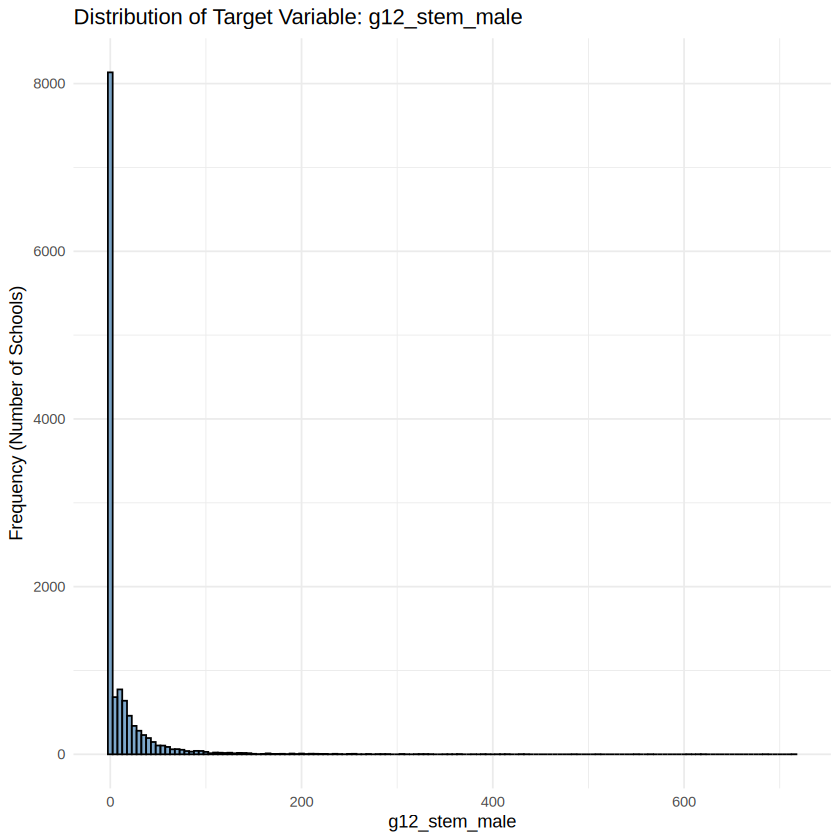

In [29]:
library(tidyverse)

# Check dimensions (Observations and Variables)
cat("Number of observations (rows):", nrow(shs_data), "\n")
cat("Number of variables (columns):", ncol(shs_data), "\n\n")

# Variable names, data types, and brief summary
glimpse(shs_data)

# Summary of Target Distribution (Mean, Median, Range)
target_summary <- summary(shs_data$g12_stem_male)
print(target_summary)
cat("Standard Deviation:", sd(shs_data$g12_stem_male, na.rm = TRUE), "\n")

# Check for Missing Values per column
missing_counts <- colSums(is.na(shs_data))
print("Missing values per column:")
print(missing_counts[missing_counts > 0])

# Check for Duplicate Rows
cat("Number of duplicate rows:", sum(duplicated(shs_data)), "\n")